In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("test.csv")

Saving test.csv to test.csv


In [3]:
print(df.head())
print(df.tail())

print(df.info())

print(df.describe())

print("Shape:", df.shape)

print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

# Removing duplicate rows
df = df.drop_duplicates()

# Check data types
print(df.dtypes)

   version       team      continent  is_host  goals_scored_last_4y  \
0     2026     France         Europe        0                    85   
1     2026      Spain         Europe        0                   104   
2     2026  Argentina  South America        0                    80   
3     2026    England         Europe        0                    82   
4     2026   Portugal         Europe        0                    98   

   goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
0                      32            25               6              7   
1                      32            29               2              8   
2                      14            30               4              3   
3                      23            26               6              7   
4                      31            26               5              7   

   world_cup_titles_before  ...  world_cup_participations_before  \
0                        2  ...                             

/tmp/ipykernel_578/458266741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=continent_count.index, y=continent_count.values, palette="viridis")


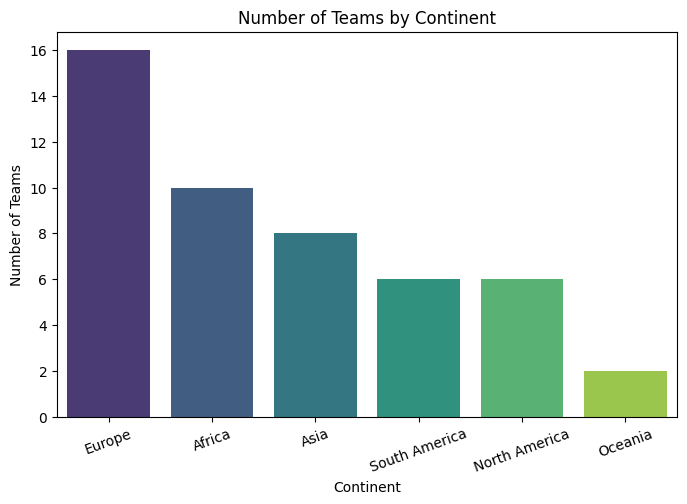

In [5]:
#Continent with highest number of teams
continent_count = df["continent"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=continent_count.index, y=continent_count.values, palette="viridis")
plt.title("Number of Teams by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Teams")
plt.xticks(rotation=20)
plt.show()

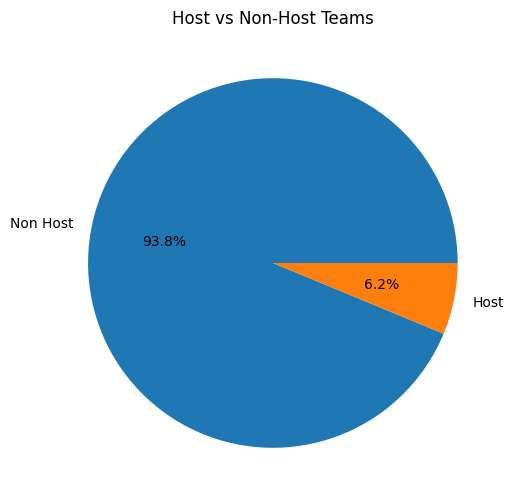

In [10]:
#Percentage of host teams

host_count = df["is_host"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(host_count,labels=["Non Host","Host"],autopct="%1.1f%%")
plt.title("Host vs Non-Host Teams")
plt.show()

/tmp/ipykernel_578/2257082435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rank.index, y=avg_rank.values,palette="magma")


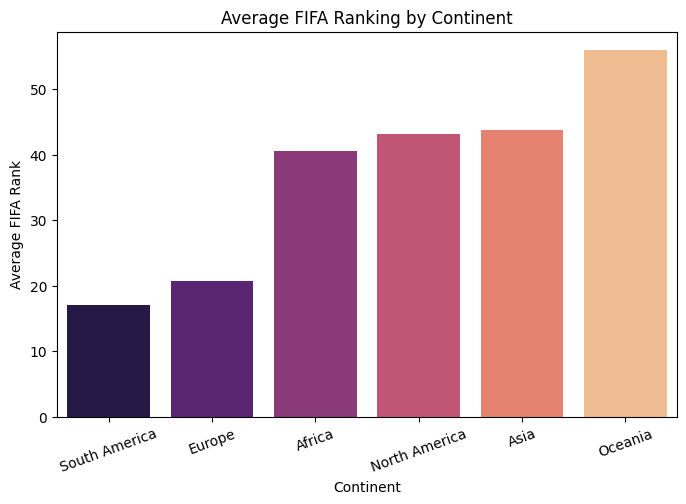

In [11]:
#Avg FIFA Ranking of each continent
avg_rank = df.groupby("continent")["fifa_rank_pre_tournament"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=avg_rank.index, y=avg_rank.values,palette="magma")
plt.title("Average FIFA Ranking by Continent")
plt.xlabel("Continent")
plt.ylabel("Average FIFA Rank")
plt.xticks(rotation=20)
plt.show()

/tmp/ipykernel_578/2449936795.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


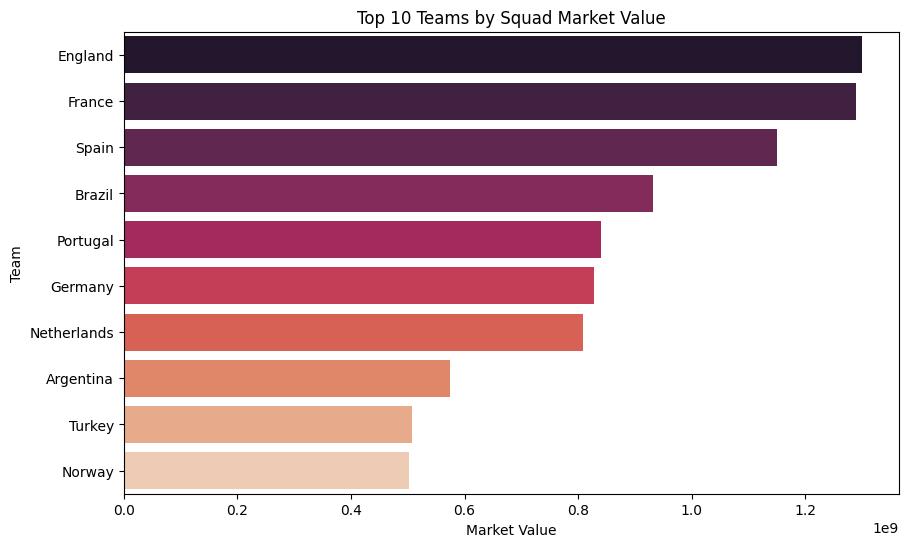

In [13]:
#Top 10 teams with highest squad market value

top10 = df.sort_values(
    by="squad_total_market_value_eur",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x="squad_total_market_value_eur",
    y="team",
    palette="rocket"
)

plt.title("Top 10 Teams by Squad Market Value")
plt.xlabel("Market Value")
plt.ylabel("Team")
plt.show()

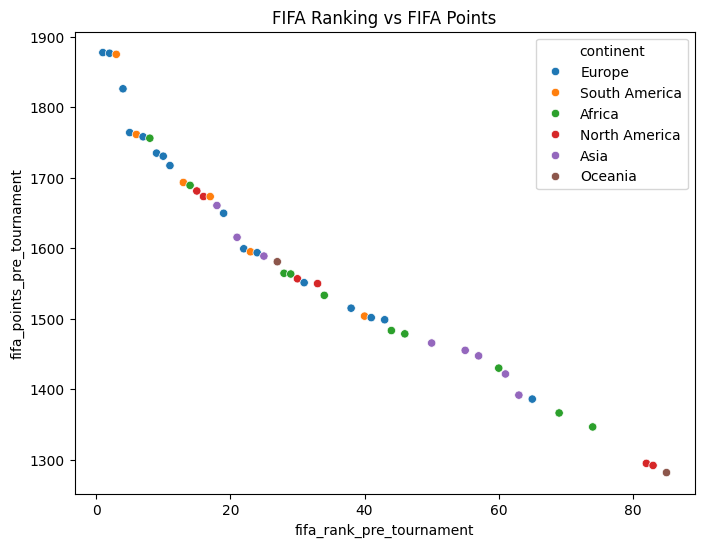

In [19]:
#Relation b/w FIFA ranking and FIFA points

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="fifa_rank_pre_tournament",
    y="fifa_points_pre_tournament",
    hue="continent"
)
plt.title("FIFA Ranking vs FIFA Points")
plt.show()

/tmp/ipykernel_578/2554299201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


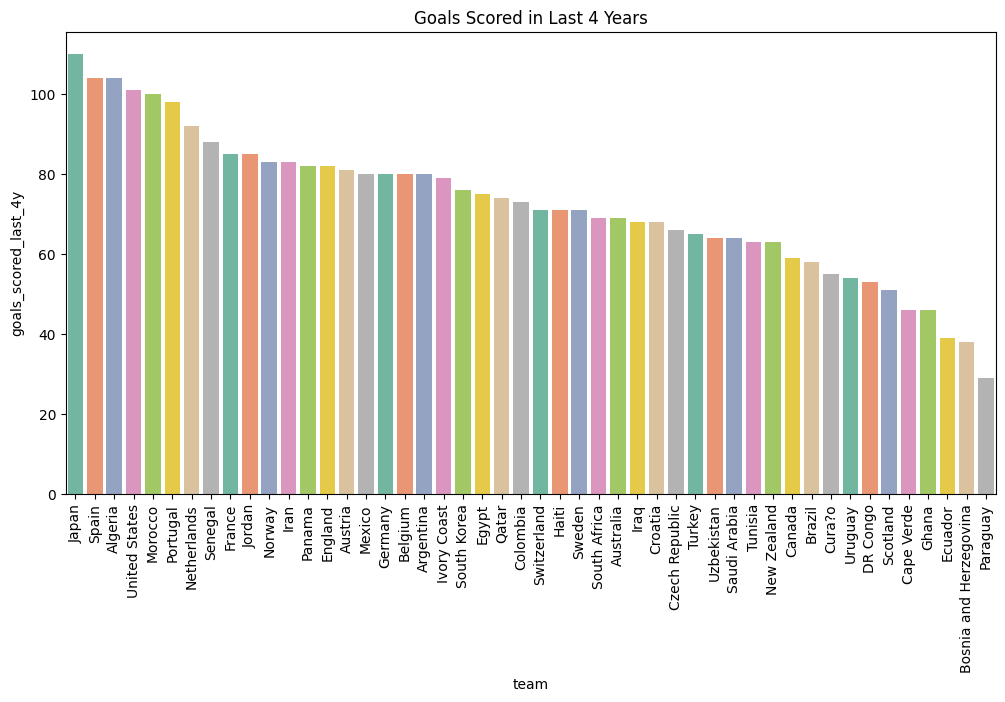

In [24]:
#Teams with most goals in last 4 yrs

top_goals = df.sort_values(
    by="goals_scored_last_4y",
    ascending=False
)

plt.figure(figsize=(12,6))
sns.barplot(
    x="team",
    y="goals_scored_last_4y",
    data=top_goals,
    palette="Set2"
)
plt.xticks(rotation=90)
plt.title("Goals Scored in Last 4 Years")
plt.show()

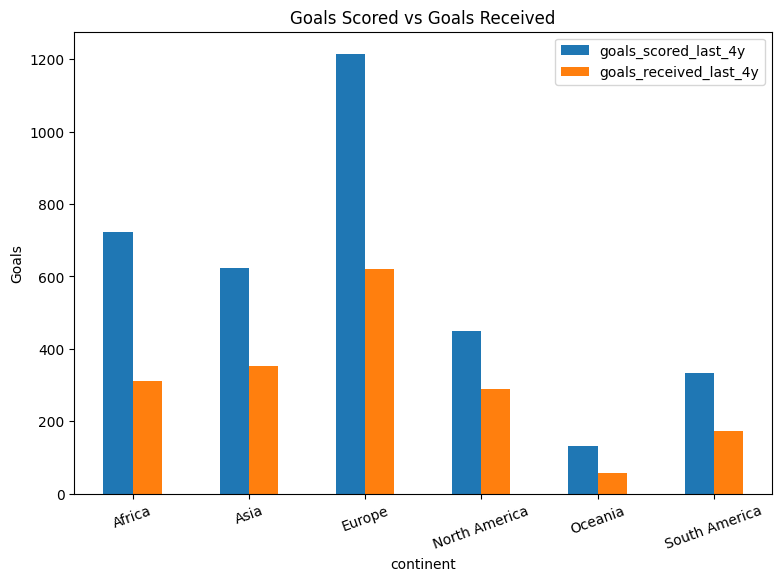

In [26]:
#Goals Scored vs Goals Received (continent)

continent_goal = df.groupby("continent")[[
    "goals_scored_last_4y",
    "goals_received_last_4y"
]].sum()

continent_goal.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Goals Scored vs Goals Received")
plt.ylabel("Goals")
plt.xticks(rotation=20)
plt.show()

/tmp/ipykernel_578/46147535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


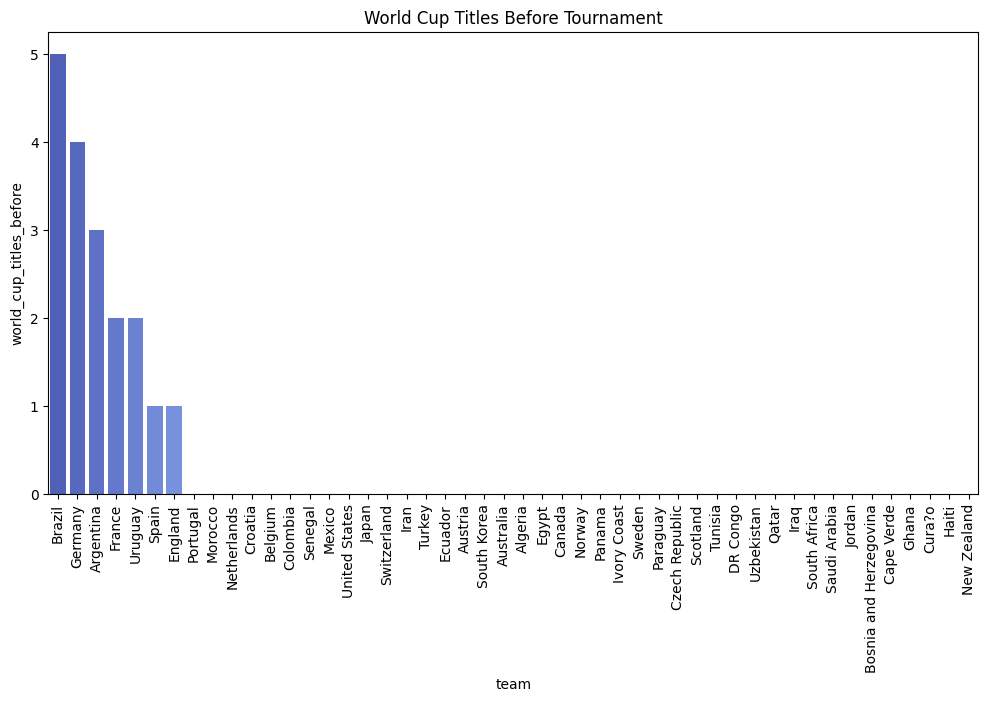

In [31]:
#Teams with most world cup titles
titles = df.sort_values(
    by="world_cup_titles_before",
    ascending=False
)

plt.figure(figsize=(12,6))
sns.barplot(
    x="team",
    y="world_cup_titles_before",
    data=titles,
    palette="coolwarm"
)
plt.xticks(rotation=90)
plt.title("World Cup Titles Before Tournament")
plt.show()

/tmp/ipykernel_578/1882647900.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


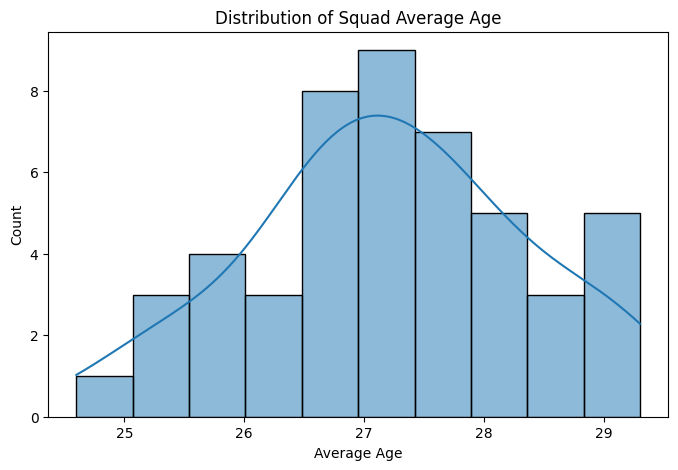

In [35]:
#Distribution of Squad Avg age

plt.figure(figsize=(8,5))
sns.histplot(
    df["squad_avg_age"],
    bins=10,
    kde=True,
    palette="rocket"
)
plt.title("Distribution of Squad Average Age")
plt.xlabel("Average Age")
plt.show()

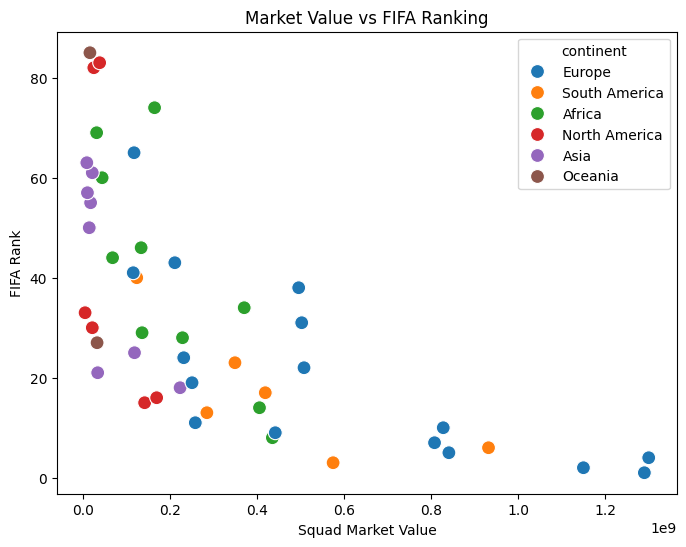

In [36]:
#Relation b/w Squad Market Value and FIFA Ranking
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="squad_total_market_value_eur",
    y="fifa_rank_pre_tournament",
    hue="continent",
    s=100
)

plt.title("Market Value vs FIFA Ranking")
plt.xlabel("Squad Market Value")
plt.ylabel("FIFA Rank")
plt.show()